In [1]:
!nvidia-smi

Mon Apr 13 22:29:12 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.86                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   34C    P0             19W /  180W |    1034MiB /  16311MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Dataset

In [40]:
import os
import cv2
import torch
import random
import shutil
import numpy as np
from tqdm import tqdm
from torchvision import transforms

# -----------------------------
# CONFIGURATION
# -----------------------------

FRAME_RATE = 25            # Target frame rate
CLIP_LEN = 16              # Number of frames per clip
RESIZE_HEIGHT = 224
CROP_SIZE = 224
TRAIN_SPLIT = 0.8           # 80% train, 20% test
SEED = 42

random.seed(SEED)

# -----------------------------
# TRANSFORMS (spatial only)
# -----------------------------
spatial_transform = transforms.Compose([
    transforms.Resize((RESIZE_HEIGHT, RESIZE_HEIGHT)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------
# UTILITY FUNCTIONS
# -----------------------------
def extract_frames(video_path, target_fps=FRAME_RATE):
    """
    Extract frames from a video at target fps.
    Returns a list of PIL tensors.
    """
    cap = cv2.VideoCapture(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS)
    if original_fps <= 0:
        original_fps = target_fps

    frame_interval = max(int(original_fps // target_fps), 1)

    frames = []
    count = 0
    success, frame = cap.read()

    while success:
        if count % frame_interval == 0:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
        success, frame = cap.read()
        count += 1

    cap.release()
    return frames

def temporal_sample(frames, clip_len=CLIP_LEN):
    """
    Sample a fixed-length clip (clip_len) from the video frames.
    If video has fewer frames than clip_len, repeat last frame.
    """
    num_frames = len(frames)

    if num_frames >= clip_len:
        start = random.randint(0, num_frames - clip_len)
        return frames[start:start + clip_len]
    else:
        # Pad with last frame if not enough frames
        last_frame = frames[-1]
        while len(frames) < clip_len:
            frames.append(last_frame)
        return frames

from PIL import Image

def save_clip_tensor(frames, output_path):
    """
    Apply spatial transforms and save the clip as a PyTorch tensor.
    """
    processed_frames = [
        spatial_transform(Image.fromarray(frame))  # <-- Convert to PIL here
        for frame in frames
    ]
    clip_tensor = torch.stack(processed_frames, dim=0)  # Shape: [T, C, H, W]
    torch.save(clip_tensor, output_path)


# -----------------------------
# MAIN PREPROCESSING
# -----------------------------
def preprocess_dataset(selected_classes, output_root, reset_output=False, DATASET_ROOT=str):
    """Preprocess the UCF101 dataset for selected classes.
    Args:
        selected_classes (list): List of class names to include.

        output_root (str): Directory to save processed data.

        reset_output (bool): If True, delete existing output directory before processing.
        
        DATASET_ROOT (str): Root directory of the raw UCF101 dataset.
    """
    print(f"Preprocessing UCF101 ({len(selected_classes)} classes) from {DATASET_ROOT} -> {output_root}")

    if reset_output and os.path.exists(output_root):
        shutil.rmtree(output_root)

    os.makedirs(output_root, exist_ok=True)

    for split_name in ["train", "val", "test"]:
        print(f"\nProcessing split: {split_name}")
        split_input_path = os.path.join(DATASET_ROOT, split_name)
        split_output_path = os.path.join(output_root, split_name)
        os.makedirs(split_output_path, exist_ok=True)

        for cls in selected_classes:
            class_input_path = os.path.join(split_input_path, cls)
            if not os.path.isdir(class_input_path):
                print(f"Warning: Class {cls} not found in {split_name}, skipping.")
                continue

            class_output_path = os.path.join(split_output_path, cls)
            os.makedirs(class_output_path, exist_ok=True)

            print(f"\n  Class: {cls}")
            videos = [
                os.path.join(class_input_path, v)
                for v in os.listdir(class_input_path)
                if v.endswith(".avi")
            ]
            videos.sort()

            for vid_path in tqdm(videos, desc=f"{cls} [{split_name}]"):
                frames = extract_frames(vid_path)
                if len(frames) == 0:
                    print(f"Skipping empty video: {vid_path}")
                    continue

                sampled_frames = temporal_sample(frames)
                video_name = os.path.splitext(os.path.basename(vid_path))[0]
                output_clip = os.path.join(class_output_path, f"{video_name}.pt")

                if os.path.exists(output_clip):
                    continue

                save_clip_tensor(sampled_frames, output_clip)

    print("\nPreprocessing completed successfully!")
    print(f"Processed data saved at: {output_root}")


In [ ]:
path = ''
DATASET_ROOT = "./ucf101-action-recognition/versions/4"
OUTPUT_ROOT = "./UCF101/processed_data"

SELECTED_CLASSES_1_TASK = ["PlayingTabla","PommelHorse","JumpingJack","PushUps","PoleVault","HorseRace","HighJump","Drumming","HorseRiding","Diving","BreastStroke",
              "TrampolineJumping","YoYo","SalsaSpin","WalkingWithDog","VolleyballSpiking","ThrowDiscus","TennisSwing","TaiChi","Swing",
              "SoccerJuggling","Skijet","Skiing","SkateBoarding","Rowing","RopeClimbing","RockClimbingIndoor","Punch","PullUps","PlayingViolin","PlayingPiano","PlayingGuitar",
              "HulaHoop","GolfSwing","Fencing","CleanAndJerk","Billiards","Biking","BenchPress","BaseballPitch"]


In [29]:

preprocess_dataset(selected_classes=SELECTED_CLASSES_1_TASK,
                   output_root=OUTPUT_ROOT,
                   reset_output=False,
                   DATASET_ROOT=DATASET_ROOT)

Preprocessing UCF101 (40 classes) from ./ucf101-action-recognition/versions/4 -> ./UCF101/processed_data

Processing split: train

  Class: PlayingTabla


PlayingTabla [train]: 100%|██████████| 83/83 [00:02<00:00, 37.00it/s]



  Class: PommelHorse


PommelHorse [train]: 100%|██████████| 92/92 [00:03<00:00, 30.35it/s]



  Class: JumpingJack


...


  Class: BenchPress


BenchPress [test]: 100%|██████████| 20/20 [00:00<00:00, 80.01it/s]



  Class: BaseballPitch


BaseballPitch [test]: 100%|██████████| 19/19 [00:00<00:00, 85.39it/s]


Preprocessing completed successfully!
Processed data saved at: ./UCF101/processed_data


# DATASET and DATALOADER

In [ ]:
path = ''
DATASET_ROOT = "./ucf101-action-recognition/versions/4"
OUTPUT_ROOT = "./UCF101/processed_data"

SELECTED_CLASSES_1_TASK = ["PlayingTabla","PommelHorse","JumpingJack","PushUps","PoleVault","HorseRace","HighJump","Drumming","HorseRiding","Diving","BreastStroke",
              "TrampolineJumping","YoYo","SalsaSpin","WalkingWithDog","VolleyballSpiking","ThrowDiscus","TennisSwing","TaiChi","Swing",
              "SoccerJuggling","Skijet","Skiing","SkateBoarding","Rowing","RopeClimbing","RockClimbingIndoor","Punch","PullUps","PlayingViolin","PlayingPiano","PlayingGuitar",
              "HulaHoop","GolfSwing","Fencing","CleanAndJerk","Billiards","Biking","BenchPress","BaseballPitch"]


In [3]:
from torch.utils.data import Dataset
import torch
import os
from glob import glob

class UCF101Clips(Dataset):
    def __init__(self, root_dir, split="train", class_names=None, class_to_idx=None):
        self.root = os.path.join(root_dir, split)

        if class_names is None:
            class_names = sorted(
                [d for d in os.listdir(self.root) if os.path.isdir(os.path.join(self.root, d))]
            )

        self.classes = class_names

        if class_to_idx is None:
            class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        self.class_to_idx = class_to_idx
        self.samples = []

        for cls_name in self.classes:
            class_dir = os.path.join(self.root, cls_name)
            if not os.path.isdir(class_dir):
                continue

            clips = glob(os.path.join(class_dir, "*.pt"))
            cls_idx = self.class_to_idx[cls_name]

            for clip in clips:
                self.samples.append((clip, cls_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = torch.load(path)
        return clip, label


In [4]:
def class_to_idx_mapping(class_names):
    "Utility function to create class name to index mapping."
    "From 0 to 39."
    return {cls_name: i for i, cls_name in enumerate(class_names)}

In [5]:
len(SELECTED_CLASSES_1_TASK)

40

In [6]:
train_dataset = UCF101Clips(root_dir=OUTPUT_ROOT, # folder where processed data is stored
            split="train",
            class_names=SELECTED_CLASSES_1_TASK,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES_1_TASK))

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, )

test_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SELECTED_CLASSES_1_TASK,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES_1_TASK))

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, )

val_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SELECTED_CLASSES_1_TASK,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES_1_TASK))

val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0,)

In [7]:
from torch.nn import LSTM
import torch
from torchvision import models


class vit_lstm(torch.nn.Module):
    def __init__(self, classes=2, name=str):
        super().__init__()
        self.classes = classes  # Number of output classes
        self.name = name

        if self.name == 'vit_b_16':
          self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
          self.vit.heads = torch.nn.Identity()  # Remove the classification head
          self.lstm = LSTM(input_size=768, hidden_size=256, num_layers=2, batch_first=True)

        self.classifier = torch.nn.Linear(256, self.classes)  # Classification layer

    def forward(self, x):
        # x: [B, T, 3, 224, 224]
        B, T, C, H, W = x.shape

        # Merge batch and time
        x = x.view(B*T, C, H, W)   # [B*T, 3, 224, 224]

        # Pass through ViT
        x = self.vit(x)            # [B*T, 768]

        # Reshape back to sequence
        x = x.view(B, T, -1)       # [B, T, 768]

        # LSTM
        x, _ = self.lstm(x)        # [B, T, 256]

        # Take last time step
        x = x[:, -1, :]            # [B, 256]

        # Classifier
        x = self.classifier(x)     # [B, classes]

        return x

In [8]:
# model loading
model_name = 'vit_b_16'

model = vit_lstm(classes=len(SELECTED_CLASSES_1_TASK), name=model_name)
model.load_state_dict(torch.load('vit_b_16_epoch_10.pth.tar'))

print("Model loaded!")


Model loaded!


In [10]:
model

vit_lstm(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
    

# Test model
Test the model on old dataset

In [9]:
# test function
# confusion matrix, accuracy, precision, recall, F1-score
# visualize confusion matrix using seaborn heatmap

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def test(model, test_loader, device='cuda', selected_classes=SELECTED_CLASSES_1_TASK):
    model.to(device)
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
    # use tqdm to show progress bar
        print("Model : ", model.name)
        for clips, labels in tqdm(test_loader, desc="Testing on test set"):
            clips = clips.to(device)
            labels = labels.to(device)

            outputs = model(clips)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics

    cm = confusion_matrix(all_labels, all_preds)


    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=selected_classes,
                yticklabels=selected_classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    # add accuracy, precision, recall, F1-score to the output
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")



DEVICE:  cuda
Model :  vit_b_16


Testing on test set:   0%|          | 0/81 [00:00<?, ?it/s]

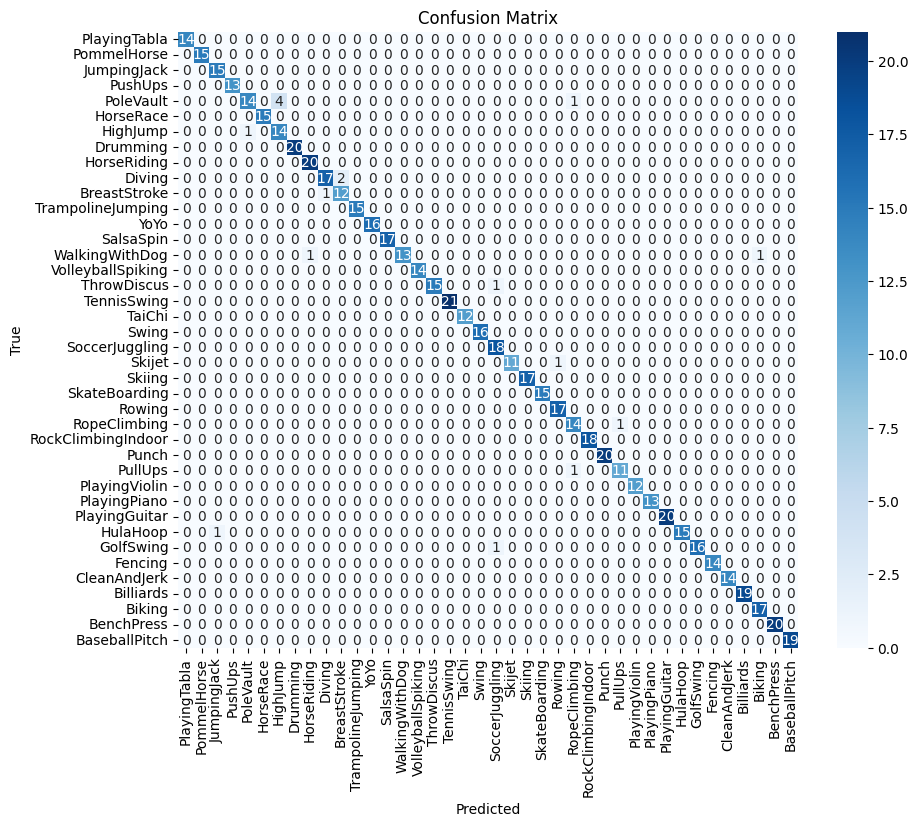

Accuracy: 0.9736
Precision: 0.9752
Recall: 0.9736
F1-score: 0.9735


In [10]:
if torch.cuda.is_available():
    device = 'cuda'
print("DEVICE: ", device)
test(model, test_loader, device=device, selected_classes=SELECTED_CLASSES_1_TASK)

# FISHER MATRIX
- Theta star

- Fisher matrix

In [13]:
val_loader.__len__(), test_loader.__len__(), train_loader.__len__()

(81, 81, 485)

In [10]:
def theta_star(model):
    "Where si the model."
    for param in model.vit.parameters():
        param.requires_grad = False

    for i, block in enumerate(model.vit.encoder.layers):
        if i >= 10 and model.name == 'vit_b_16':
            for param in block.parameters(): param.requires_grad = True
    
    for param in model.lstm.parameters(): param.requires_grad = True
    
    for param in model.classifier.parameters(): param.requires_grad = True

    theta_star = {
        n: p.clone().detach()
        for n, p in model.named_parameters()
        if p.requires_grad
    }

    return theta_star

In [11]:
theta_opt = theta_star(model)

In [12]:
theta_opt

{'vit.encoder.layers.encoder_layer_10.ln_1.weight': tensor([ 0.2828,  0.3272,  0.2795,  0.2901,  0.2635,  0.3281, -0.0971, -0.0877,
          0.2940,  0.3218,  0.1530,  0.2392,  0.2405,  0.2022,  0.0784,  0.3116,
          0.1020,  0.2039,  0.1660,  0.2221,  0.3149,  0.2806,  0.2710, -0.1040,
          0.1495,  0.2656,  0.2647,  0.2008,  0.2387,  0.1546,  0.1979,  0.2450,
         -0.1016,  0.2943,  0.3058,  0.2068,  0.2877,  0.1850,  0.2938,  0.3310,
          0.2476,  0.2046,  0.3184,  0.2685,  0.2468,  0.2976,  0.2706,  0.2968,
          0.2981,  0.2303,  0.2247,  0.0769,  0.2503,  0.2286,  0.3150,  0.3041,
          0.3168,  0.2861,  0.2826,  0.1025,  0.2503,  0.2171, -0.0111,  0.2995,
          0.1376,  0.2778,  0.2534,  0.3195,  0.2834,  0.2621,  0.3201,  0.3041,
          0.3331,  0.2973,  0.2551,  0.2807,  0.2430,  0.2428,  0.3261, -0.0859,
         -0.0655,  0.1798,  0.2599,  0.1722,  0.3224,  0.2830,  0.2919,  0.3363,
          0.2176,  0.2218,  0.2935,  0.2377,  0.0942,  0.3

In [15]:
from tqdm.auto import tqdm

def getFisherDiagonal(train_loader, model, fishermax=1e6, device='cuda'):


    for param in model.vit.parameters():
        param.requires_grad = False

    for i, block in enumerate(model.vit.encoder.layers):
        if i >= 10 and model.name == 'vit_b_16':
            for param in block.parameters(): param.requires_grad = True
    
    for param in model.lstm.parameters(): param.requires_grad = True
    
    for param in model.classifier.parameters(): param.requires_grad = True

    fisher = {
        n: torch.zeros_like(p, device=device)
        for n, p in model.named_parameters()
        if p.requires_grad
    }

    model.train()
    model.to(device)


    for module in model.modules():
        if isinstance(module, torch.nn.Dropout):
            module.eval()


    for inputs, targets in tqdm(train_loader, desc="Computing Fisher"):
        inputs = inputs.to(device)
        targets = targets.to(device)

        model.zero_grad(set_to_none=True)

        logits = model(inputs)
        loss = torch.nn.functional.cross_entropy(logits, targets)

        loss.backward()

        for n, p in model.named_parameters():
            if p.grad is not None:
                fisher[n] += p.grad.pow(2)

    # average over batches (standard)
    for n in fisher:
        fisher[n] /= len(train_loader.dataset)
        fisher[n] = torch.clamp(fisher[n], min=0.0, max=1.0)

    return fisher

In [14]:
val_loader.__len__(), len(val_loader.dataset)
train_loader.__len__(), len(train_loader.dataset)

(485, 3877)

In [16]:
fisher_mat = getFisherDiagonal(val_loader, model, fishermax=1e6, device='cuda')

Computing Fisher:   0%|          | 0/81 [00:00<?, ?it/s]

# NEW DATASET

In [17]:
SUBSET_2 = [
    "ApplyEyeMakeup",
    "ApplyLipstick",
    "Archery",
    "BabyCrawling",
    "BalanceBeam",
    "BandMarching",
    "BlowDryHair",
    "BlowingCandles",
    "BodyWeightSquats",
    "Bowling",
]

print("Classes in SUBSET_2 that are also in SELECTED_CLASSES_1_TASK:")
for cls in SUBSET_2:
    if cls in SELECTED_CLASSES_1_TASK: print(cls)

Classes in SUBSET_2 that are also in SELECTED_CLASSES_1_TASK:


In [41]:
preprocess_dataset(selected_classes=SUBSET_2,
                    output_root=OUTPUT_ROOT,
                    reset_output=False,
                    DATASET_ROOT=DATASET_ROOT)

Preprocessing UCF101 (10 classes) from ./ucf101-action-recognition/versions/4 -> ./UCF101/processed_data

Processing split: train

  Class: ApplyEyeMakeup


ApplyEyeMakeup [train]: 100%|██████████| 108/108 [00:05<00:00, 20.28it/s]



  Class: ApplyLipstick


ApplyLipstick [train]: 100%|██████████| 85/85 [00:04<00:00, 20.51it/s]



  Class: Archery


...


  Class: BodyWeightSquats


BodyWeightSquats [test]: 100%|██████████| 14/14 [00:00<00:00, 22.68it/s]



  Class: Bowling


Bowling [test]: 100%|██████████| 20/20 [00:00<00:00, 21.55it/s]


Preprocessing completed successfully!
Processed data saved at: ./UCF101/processed_data


In [18]:
def class_to_idx_task_2(class_names,):
    "Create class to index mapping for a specific task."
    "from 40 to 49"
    return {cls_name: 40 + i for i, cls_name in enumerate(class_names)}


In [19]:
class_to_idx_task_2(SUBSET_2)

{'ApplyEyeMakeup': 40,
 'ApplyLipstick': 41,
 'Archery': 42,
 'BabyCrawling': 43,
 'BalanceBeam': 44,
 'BandMarching': 45,
 'BlowDryHair': 46,
 'BlowingCandles': 47,
 'BodyWeightSquats': 48,
 'Bowling': 49}

In [20]:
train_dataset = UCF101Clips(root_dir=OUTPUT_ROOT, # folder where processed data is stored
            split="train",
            class_names=SUBSET_2,
            class_to_idx=class_to_idx_task_2(SUBSET_2))

train_loader_2 = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, ) 

test_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="test",
            class_names=SUBSET_2,
            class_to_idx=class_to_idx_task_2(SUBSET_2))

test_loader_2 = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, )

val_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SUBSET_2,
            class_to_idx=class_to_idx_task_2(SUBSET_2)) 

val_loader_2 = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0,)

In [22]:
# Inspect one batch from train_loader
clips, labels = next(iter(train_loader_2))

print("Clips shape:", clips.shape) # Expected: [B, T, C, H, W]
print("Clips dtype:", clips.dtype)
print("Labels shape:", labels.shape)
print("Labels dtype:", labels.dtype)
print("Labels:", labels.tolist())
print("Unique labels in batch:", torch.unique(labels).tolist())

if clips.ndim == 5:
    print(f"Batch size: {clips.shape[0]}")
    print(f"Temporal length: {clips.shape[1]}")
    print(f"Channels: {clips.shape[2]}")
    print(f"Height: {clips.shape[3]}")
    print(f"Width: {clips.shape[4]}")

Clips shape: torch.Size([8, 16, 3, 224, 224])
Clips dtype: torch.float32
Labels shape: torch.Size([8])
Labels dtype: torch.int64
Labels: [44, 49, 46, 48, 49, 43, 43, 48]
Unique labels in batch: [43, 44, 46, 48, 49]
Batch size: 8
Temporal length: 16
Channels: 3
Height: 224
Width: 224


# MODEL
New model for 50 classes

In [21]:
old_weights_data = model.classifier.weight.data.clone()
old_bias_data = model.classifier.bias.data.clone()

# Create a new classifier with the desired number of output features (50)
model.classifier = torch.nn.Linear(256, 50) # Ensure new layer is on the same device

# Copy the old weights data to the new classifier's weight.data
# The number of output features in the old classifier was len(SELECTED_CLASSES), which is 40.
# So, we copy 40 rows from old_weights_data.
model.classifier.weight.data[:old_weights_data.shape[0]] = old_weights_data
model.classifier.bias.data[:old_bias_data.shape[0]] = old_bias_data

# Corrected line to print the shape
print(model.classifier.weight.shape)
print(model.classifier.bias.shape)

torch.Size([50, 256])
torch.Size([50])


In [22]:
model

vit_lstm(
  (vit): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
    

# Test new model on the dataset
- Old task
- New task 
- Total 


In [23]:
SELECTED_CLASSES_2_TASK = SELECTED_CLASSES_1_TASK + SUBSET_2
class_to_idx_mapping(SELECTED_CLASSES_2_TASK)


{'PlayingTabla': 0,
 'PommelHorse': 1,
 'JumpingJack': 2,
 'PushUps': 3,
 'PoleVault': 4,
 'HorseRace': 5,
 'HighJump': 6,
 'Drumming': 7,
 'HorseRiding': 8,
 'Diving': 9,
 'BreastStroke': 10,
 'TrampolineJumping': 11,
 'YoYo': 12,
 'SalsaSpin': 13,
 'WalkingWithDog': 14,
 'VolleyballSpiking': 15,
 'ThrowDiscus': 16,
 'TennisSwing': 17,
 'TaiChi': 18,
 'Swing': 19,
 'SoccerJuggling': 20,
 'Skijet': 21,
 'Skiing': 22,
 'SkateBoarding': 23,
 'Rowing': 24,
 'RopeClimbing': 25,
 'RockClimbingIndoor': 26,
 'Punch': 27,
 'PullUps': 28,
 'PlayingViolin': 29,
 'PlayingPiano': 30,
 'PlayingGuitar': 31,
 'HulaHoop': 32,
 'GolfSwing': 33,
 'Fencing': 34,
 'CleanAndJerk': 35,
 'Billiards': 36,
 'Biking': 37,
 'BenchPress': 38,
 'BaseballPitch': 39,
 'ApplyEyeMakeup': 40,
 'ApplyLipstick': 41,
 'Archery': 42,
 'BabyCrawling': 43,
 'BalanceBeam': 44,
 'BandMarching': 45,
 'BlowDryHair': 46,
 'BlowingCandles': 47,
 'BodyWeightSquats': 48,
 'Bowling': 49}

DEVICE:  cuda
Model :  vit_b_16


Testing on test set:   0%|          | 0/81 [00:00<?, ?it/s]

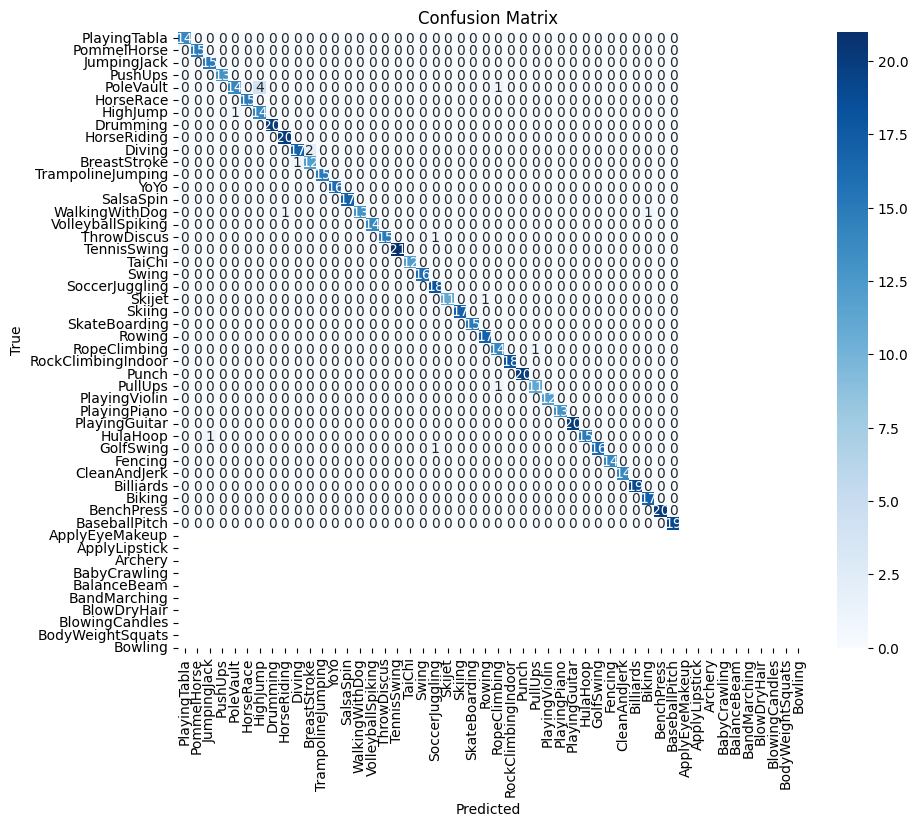

Accuracy: 0.9736
Precision: 0.9752
Recall: 0.9736
F1-score: 0.9735


In [26]:
if torch.cuda.is_available():
    device = 'cuda'
print("DEVICE: ", device)
test(model, test_loader, device=device, selected_classes=SELECTED_CLASSES_2_TASK)

DEVICE:  cuda
Model :  vit_b_16


Testing on test set:   0%|          | 0/22 [00:00<?, ?it/s]

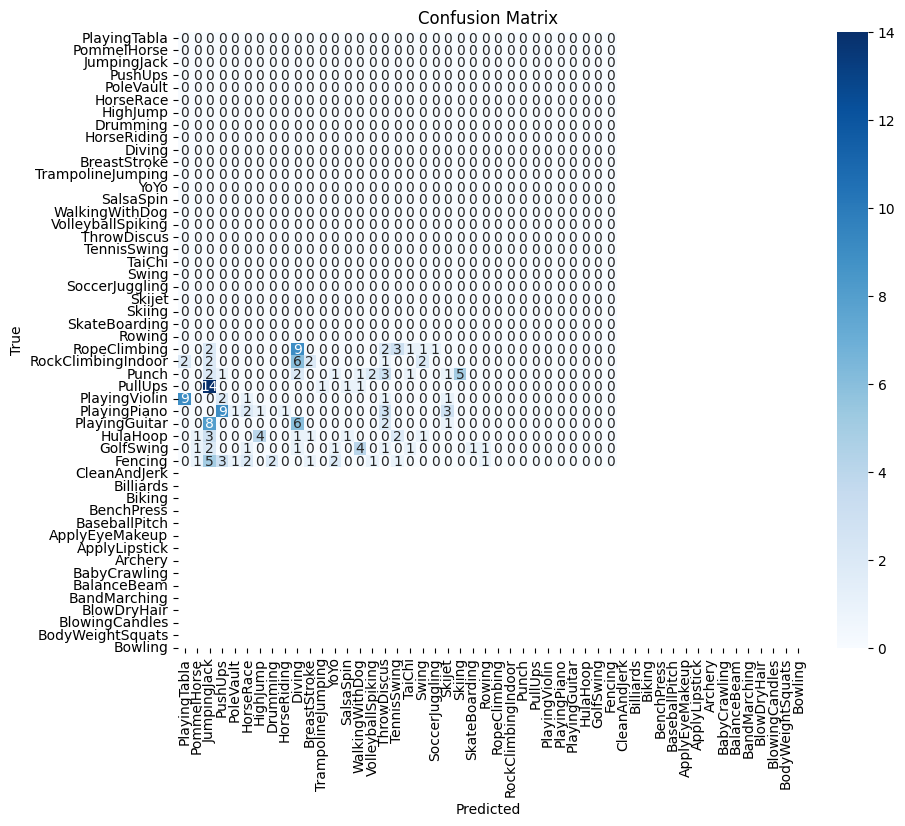

Accuracy: 0.0000
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000


c:\Users\guzun\miniconda3\envs\apai\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\guzun\miniconda3\envs\apai\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [27]:
if torch.cuda.is_available():
    device = 'cuda'
print("DEVICE: ", device)
test(model, test_loader_2, device=device, selected_classes=SELECTED_CLASSES_2_TASK)

In [24]:
SELECTED_CLASSES_2_TASK = SELECTED_CLASSES_1_TASK + SUBSET_2

train_dataset = UCF101Clips(root_dir=OUTPUT_ROOT, # folder where processed data is stored
            split="train",
            class_names=SELECTED_CLASSES_2_TASK,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES_2_TASK))

train_loader_task_2_tot = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0, ) 

test_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="test",
            class_names=SELECTED_CLASSES_2_TASK,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES_2_TASK))

test_loader_task_2_tot = torch.utils.data.DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0, )

val_dataset = UCF101Clips(root_dir=OUTPUT_ROOT,
            split="val",
            class_names=SELECTED_CLASSES_2_TASK,
            class_to_idx=class_to_idx_mapping(SELECTED_CLASSES_2_TASK)) 

val_loader_task_2_tot = torch.utils.data.DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0,)

DEVICE:  cuda
Model :  vit_b_16


Testing on test set:   0%|          | 0/104 [00:00<?, ?it/s]

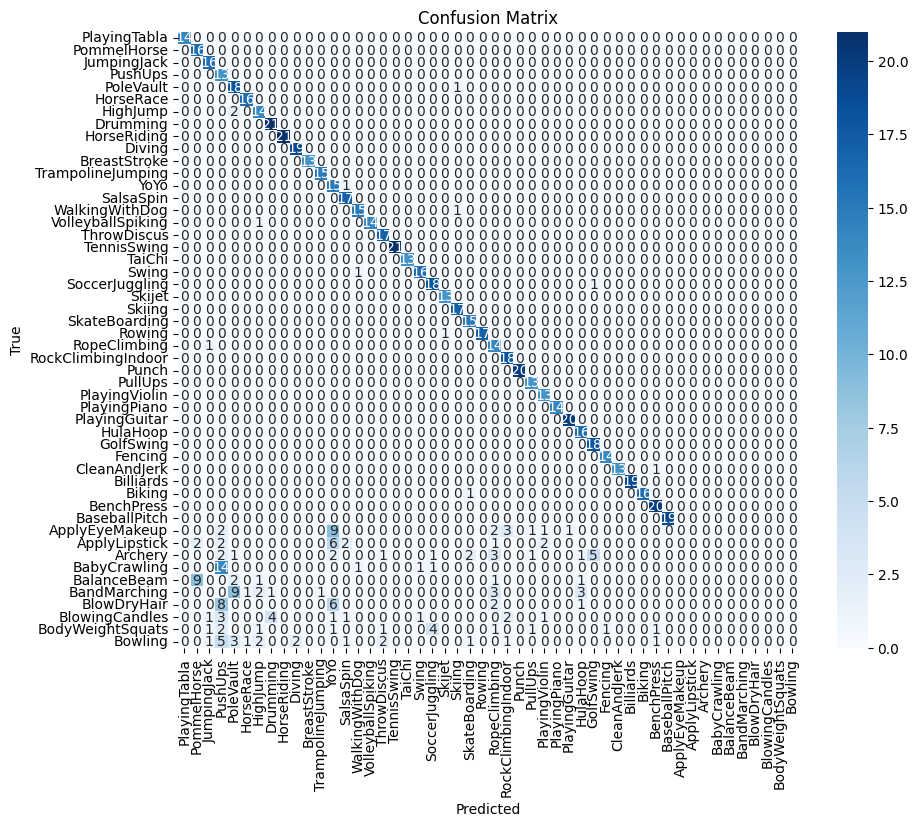

Accuracy: 0.7825
Precision: 0.6711
Recall: 0.7825
F1-score: 0.7137


c:\Users\guzun\miniconda3\envs\apai\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [29]:
if torch.cuda.is_available():
    device = 'cuda'
print("DEVICE: ", device)
test(model, test_loader_task_2_tot, device=device, selected_classes=SELECTED_CLASSES_2_TASK)

# TRAINING 
- 

In [25]:
from matplotlib import pyplot as plt
def accuracy_curve(train_accuracies, val_accuracies, task =str):
    plt.figure(figsize=(10, 5))
    plt.plot(train_accuracies, label='Train Accuracy')
    plt.plot(val_accuracies, label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy Curve on ' + task)
    plt.legend()
    plt.grid()
    plt.show()

def loss_curve(train_losses, val_losses, task=str):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curve on ' + task)
    plt.legend()
    plt.grid()
    plt.show()

In [26]:
def compute_ewc_loss(model, theta_star, fisher, lambda_ewc=5000, device='cuda'):
    ewc_loss = 0.0

    for n, p in model.named_parameters():
        if p.requires_grad and n in theta_star and n in fisher:
            old = theta_star[n].to(device)
            f = fisher[n].to(device)

            # SAFE handling
            if p.shape == old.shape:
                ewc_loss += (f * (p - old).pow(2)).sum()
            else:
                # handle classifier expansion
                if len(p.shape) == 2:  # weight [C, D]
                    c_old = old.shape[0]
                    ewc_loss += (f[:c_old] *
                                 (p[:c_old] - old).pow(2)).sum()

                elif len(p.shape) == 1:  # bias [C]
                    c_old = old.shape[0]
                    ewc_loss += (f[:c_old] *
                                 (p[:c_old] - old).pow(2)).sum()

    return lambda_ewc * ewc_loss

In [27]:
    # train function
    # plot loss curve for train and validation
    # plot accuracy curve
    # during evaluation use the previous test function to compute metrics and visualize confusion matrix
    # save the model at the end of each epoch

from matplotlib import pyplot as plt
import torch
from tqdm.auto import tqdm
def train_cl(model, new_task_train_loader, new_task_val_loader, old_task_val_loader, device='cuda', epochs=10, lr=1e-5, theta_star=None, fisher=None):

    model.to(device)
    

    if model.name == 'vit_b_16':
        for param in model.vit.parameters():
            param.requires_grad = False

        for i, block in enumerate(model.vit.encoder.layers):
            if i >= 10 and model.name == 'vit_b_16':
                for param in block.parameters(): param.requires_grad = True
    
    for param in model.lstm.parameters(): param.requires_grad = True
    
    for param in model.classifier.parameters(): param.requires_grad = True

    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    train_losses = []
    val_losses_new_task = []
    val_losses_old_task = []
    train_accuracies = []
    val_accuracies_new_task = []
    val_accuracies_old_task = []

    for epoch in range(epochs):
        model.train()

        for module in model.modules():
            if isinstance(module, torch.nn.Dropout):
                module.eval()

        epoch_loss = 0
        correct = 0
        total = 0
        for clips, labels in tqdm(new_task_train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
            clips = clips.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(clips)

            # TO DO
            # compute ewc loss

            loss = criterion(outputs, labels) + compute_ewc_loss(model, theta_star, fisher)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
        train_loss = epoch_loss / len(new_task_train_loader)
        train_accuracy = correct / total
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}")

        # Validation
        model.eval()
        val_losses_new_task_epoch = 0
        correct_new_task = 0
        total_new_task = 0

        with torch.no_grad():
            for clips, labels in tqdm(new_task_val_loader, desc=f"Epoch {epoch+1}/{epochs} - Validation"):
                clips = clips.to(device)
                labels = labels.to(device)

                outputs = model(clips)

                loss = criterion(outputs, labels)
                val_losses_new_task_epoch += loss.item()

                predicted = torch.argmax(outputs, dim=1)
                correct_new_task += (predicted == labels).sum().item()
                total_new_task += labels.size(0)
        val_losses_new_task_epoch /= len(new_task_val_loader)
        val_accuracy = correct_new_task / total_new_task
        val_losses_new_task .append(val_losses_new_task_epoch)
        val_accuracies_new_task.append(val_accuracy)
        print(f"Epoch {epoch+1}/{epochs} - Val Loss: {val_losses_new_task_epoch:.4f}, Val Accuracy: {val_accuracy:.4f}")   



        val_losses_old_task_epoch = 0
        correct_old_task = 0
        total_old_task = 0

        with torch.no_grad():
            for clips, labels in tqdm(old_task_val_loader, desc=f"Epoch {epoch+1}/{epochs} - Old Task Validation"):
                clips = clips.to(device)
                labels = labels.to(device)

                outputs = model(clips)

                # TO DO
                # compute ewc loss
                loss = criterion(outputs, labels)
                val_losses_old_task_epoch += loss.item()

                predicted = torch.argmax(outputs, dim=1)
                correct_old_task += (predicted == labels).sum().item()
                total_old_task += labels.size(0)
        val_loss_old_task = val_losses_old_task_epoch / len(old_task_val_loader)
        val_accuracy_old_task = correct_old_task / total_old_task
        val_losses_old_task.append(val_loss_old_task)
        val_accuracies_old_task.append(val_accuracy_old_task)
        print(f"Epoch {epoch+1}/{epochs} - Old Task Val Loss: {val_losses_old_task_epoch:.4f}, Old Task Val Accuracy: {val_accuracy_old_task:.4f}")




    # TO DO 
    # accuracy on old task, accuracy on new task
    # loss curve for old task, loss curve for new task
    accuracy_curve(train_accuracies, val_accuracies_new_task, task="New Task")
    loss_curve(train_losses, val_losses_new_task, task="New Task")

    accuracy_curve(train_accuracies, val_accuracies_old_task, task="Old Task")
    loss_curve(train_losses, val_losses_old_task, task="Old Task")

        # Save model
    torch.save(model.state_dict(), f"Continual_learning_{model.name}_epoch_{epoch+1}.pth.tar")
    print(f"Model saved: Continual_learning_{model.name}_epoch_{epoch+1}.pth.tar")



DEVICE:  cuda


Epoch 1/3 - Training:   0%|          | 0/122 [00:00<?, ?it/s]

Epoch 1/3 - Train Loss: 3.9192, Train Accuracy: 0.0123


Epoch 1/3 - Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 1/3 - Val Loss: 2.9653, Val Accuracy: 0.1056


...

Epoch 3/3 - Train Loss: 1.9420, Train Accuracy: 0.7920


Epoch 3/3 - Validation:   0%|          | 0/21 [00:00<?, ?it/s]

Epoch 3/3 - Val Loss: 1.7089, Val Accuracy: 0.8634


Epoch 3/3 - Old Task Validation:   0%|          | 0/81 [00:00<?, ?it/s]

Epoch 3/3 - Old Task Val Loss: 84.1081, Old Task Val Accuracy: 0.8047


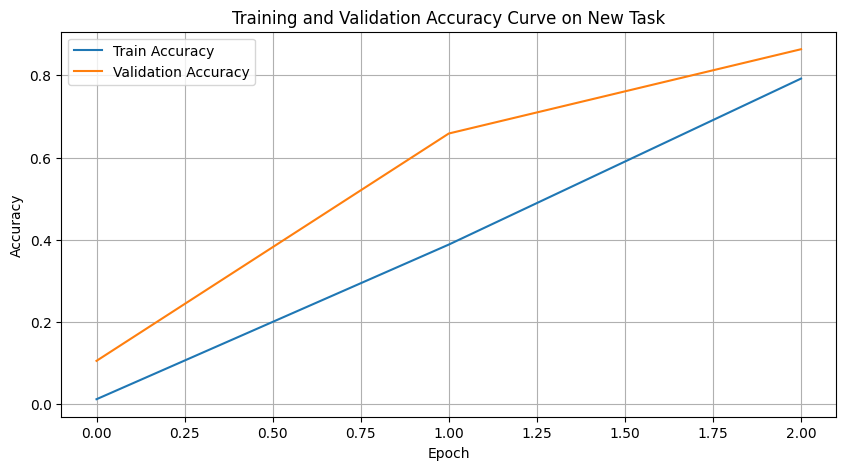

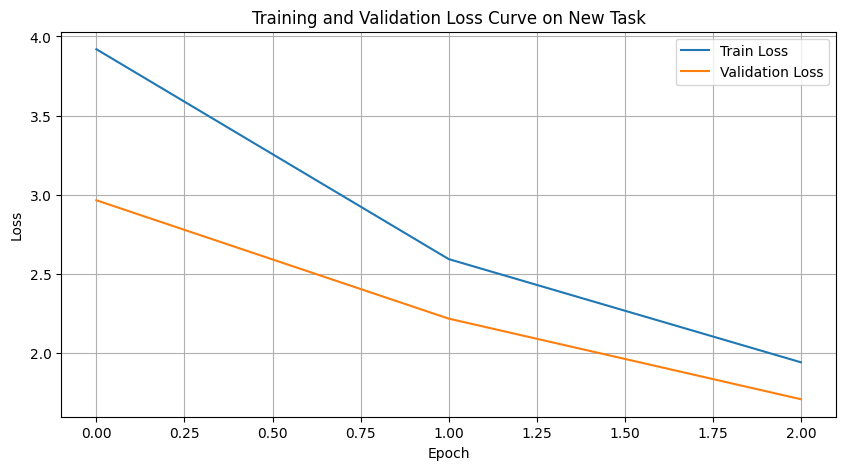

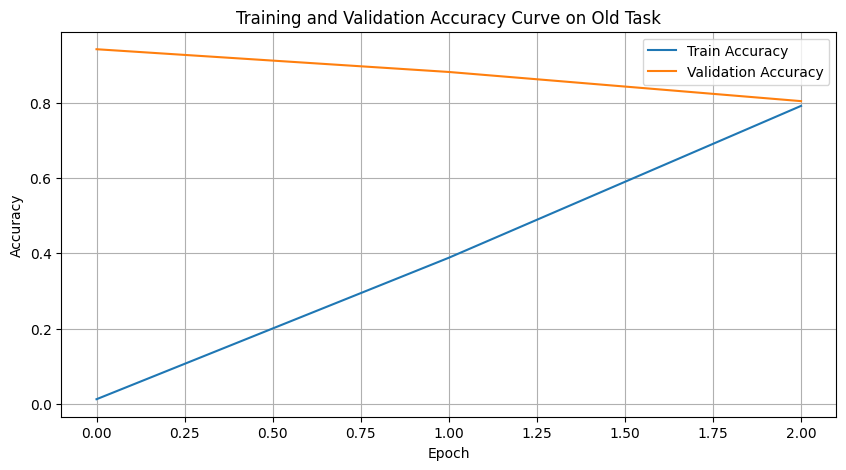

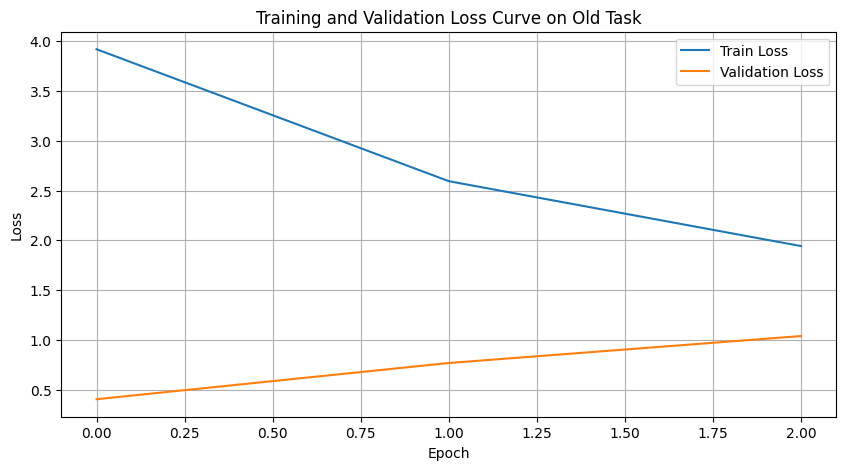

Model saved: Continual_learning_vit_b_16_epoch_3.pth.tar


In [28]:
if torch.cuda.is_available():
    device = 'cuda'
print("DEVICE: ", device)
train_cl(model, train_loader_2, val_loader_2, val_loader, device=device, epochs=3, lr=1e-5, theta_star=theta_opt, fisher=fisher_mat)

Model :  vit_b_16


Testing on test set:   0%|          | 0/104 [00:00<?, ?it/s]

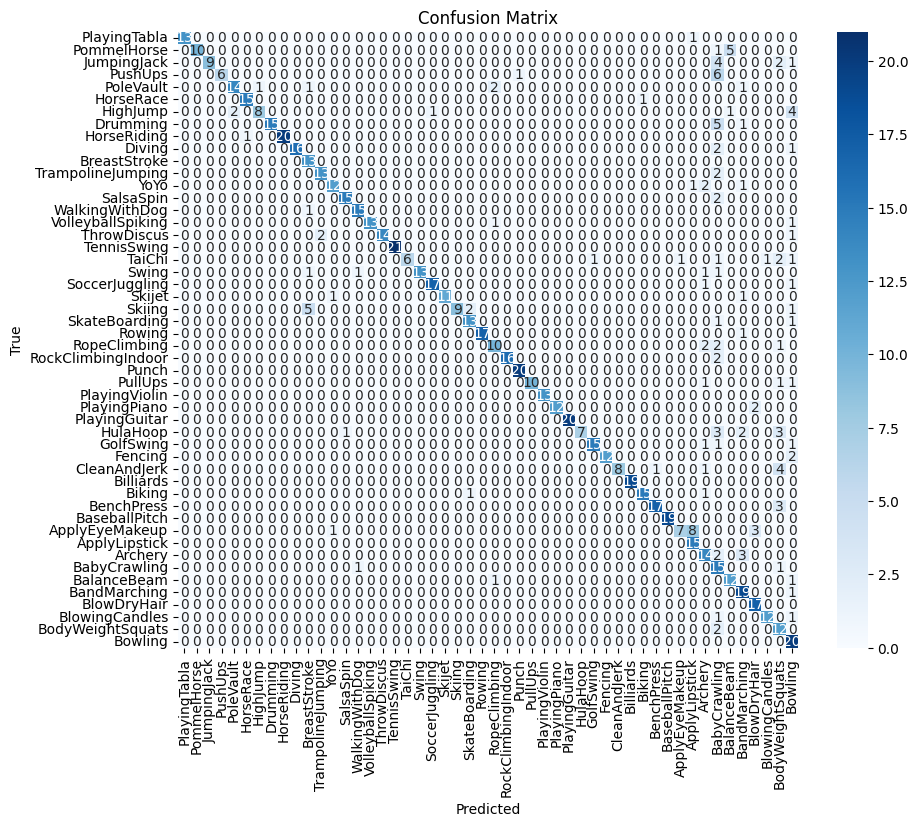

Accuracy: 0.8221
Precision: 0.8886
Recall: 0.8221
F1-score: 0.8305


In [29]:
test(model, test_loader_task_2_tot, selected_classes=SELECTED_CLASSES_2_TASK)